In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('/content/Walmart.csv')

In [2]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [6]:
df.shape

(6435, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


Data Cleaning

In [12]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [44]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


EDA

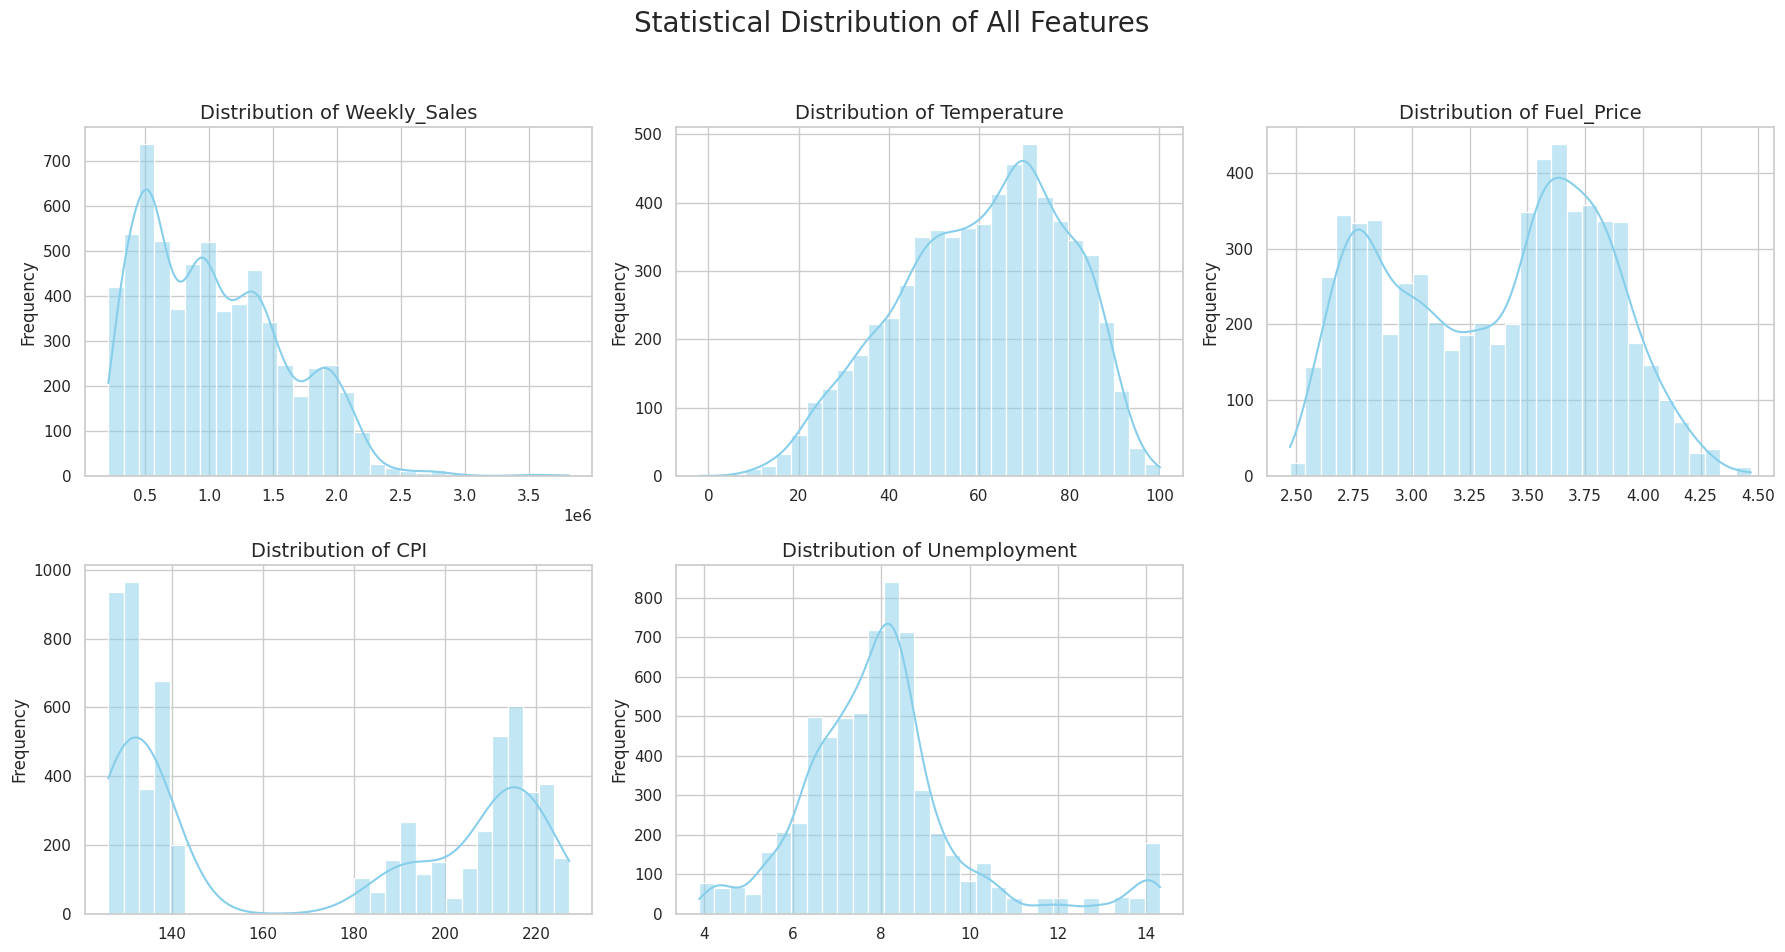

In [23]:
cols_to_plot = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
fig.suptitle('Statistical Distribution of All Features', fontsize=20)

for i, col in enumerate(cols_to_plot):
    # حساب مكان الرسمة (السطر والعمود)
    row = i // 3
    column = i % 3

    sns.histplot(df[col], kde=True, ax=axes[row, column], color='skyblue', bins=30)

    axes[row, column].set_title(f'Distribution of {col}', fontsize=14)
    axes[row, column].set_xlabel('')
    axes[row, column].set_ylabel('Frequency')

fig.delaxes(axes[1, 2])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Weekly Sales Distribution: Values are concentrated between 0.5 and 2.5. The plot shows a right-skewed distribution (positive skew), indicating the presence of outliers.

Temperature Distribution: The distribution is approximately normal with no significant issues; note that the temperature is measured in Fahrenheit.

Fuel Price and CPI (Inflation) Distribution: Both distributions are bimodal, which means there are two distinct peaks (two most frequent values) in the data.

Unemployment Rate Distribution: The distribution is centered around 8%.

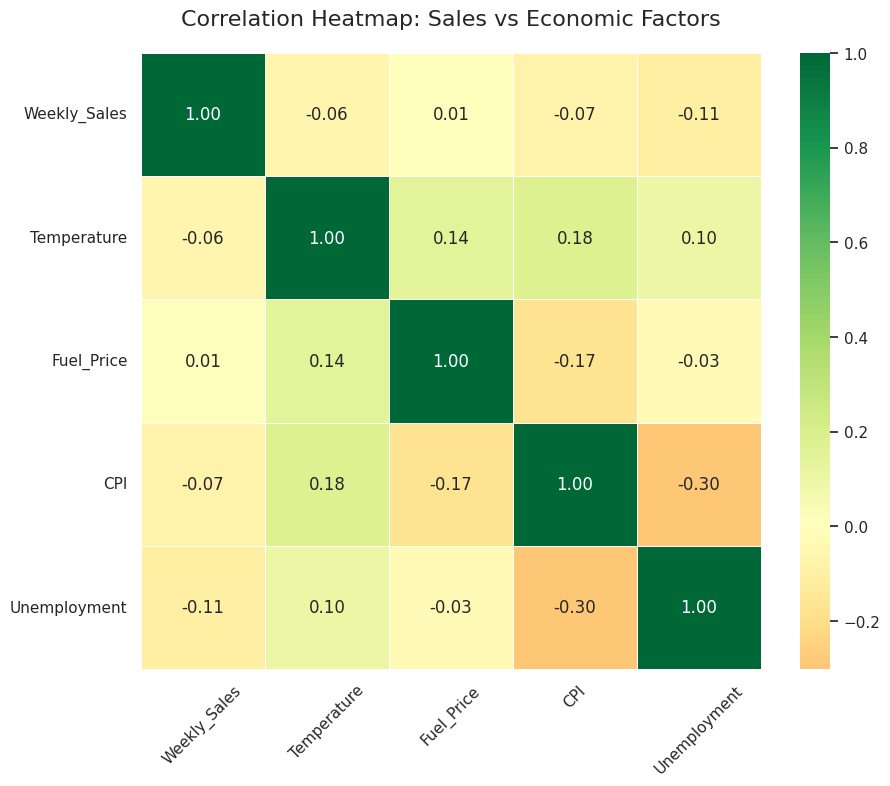

In [26]:
# --- 1. Correlation Matrix Calculation ---
correlation_matrix = df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']].corr()

# --- 2. Visualization (Heatmap) ---
plt.figure(figsize=(10, 8))

# Drawing the Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', center=0, linewidths=0.5, fmt=".2f")

# Adding professional titles and labels
plt.title('Correlation Heatmap: Sales vs Economic Factors', fontsize=16, pad=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# Display the plot
plt.show()

Inverse Relationships: The visualization shows an inverse (negative) relationship between Weekly Sales and the following variables: Temperature, CPI (Inflation), and Unemployment Rate.

Positive Relationship: There is a very slight positive correlation between Fuel Price and Weekly Sales.

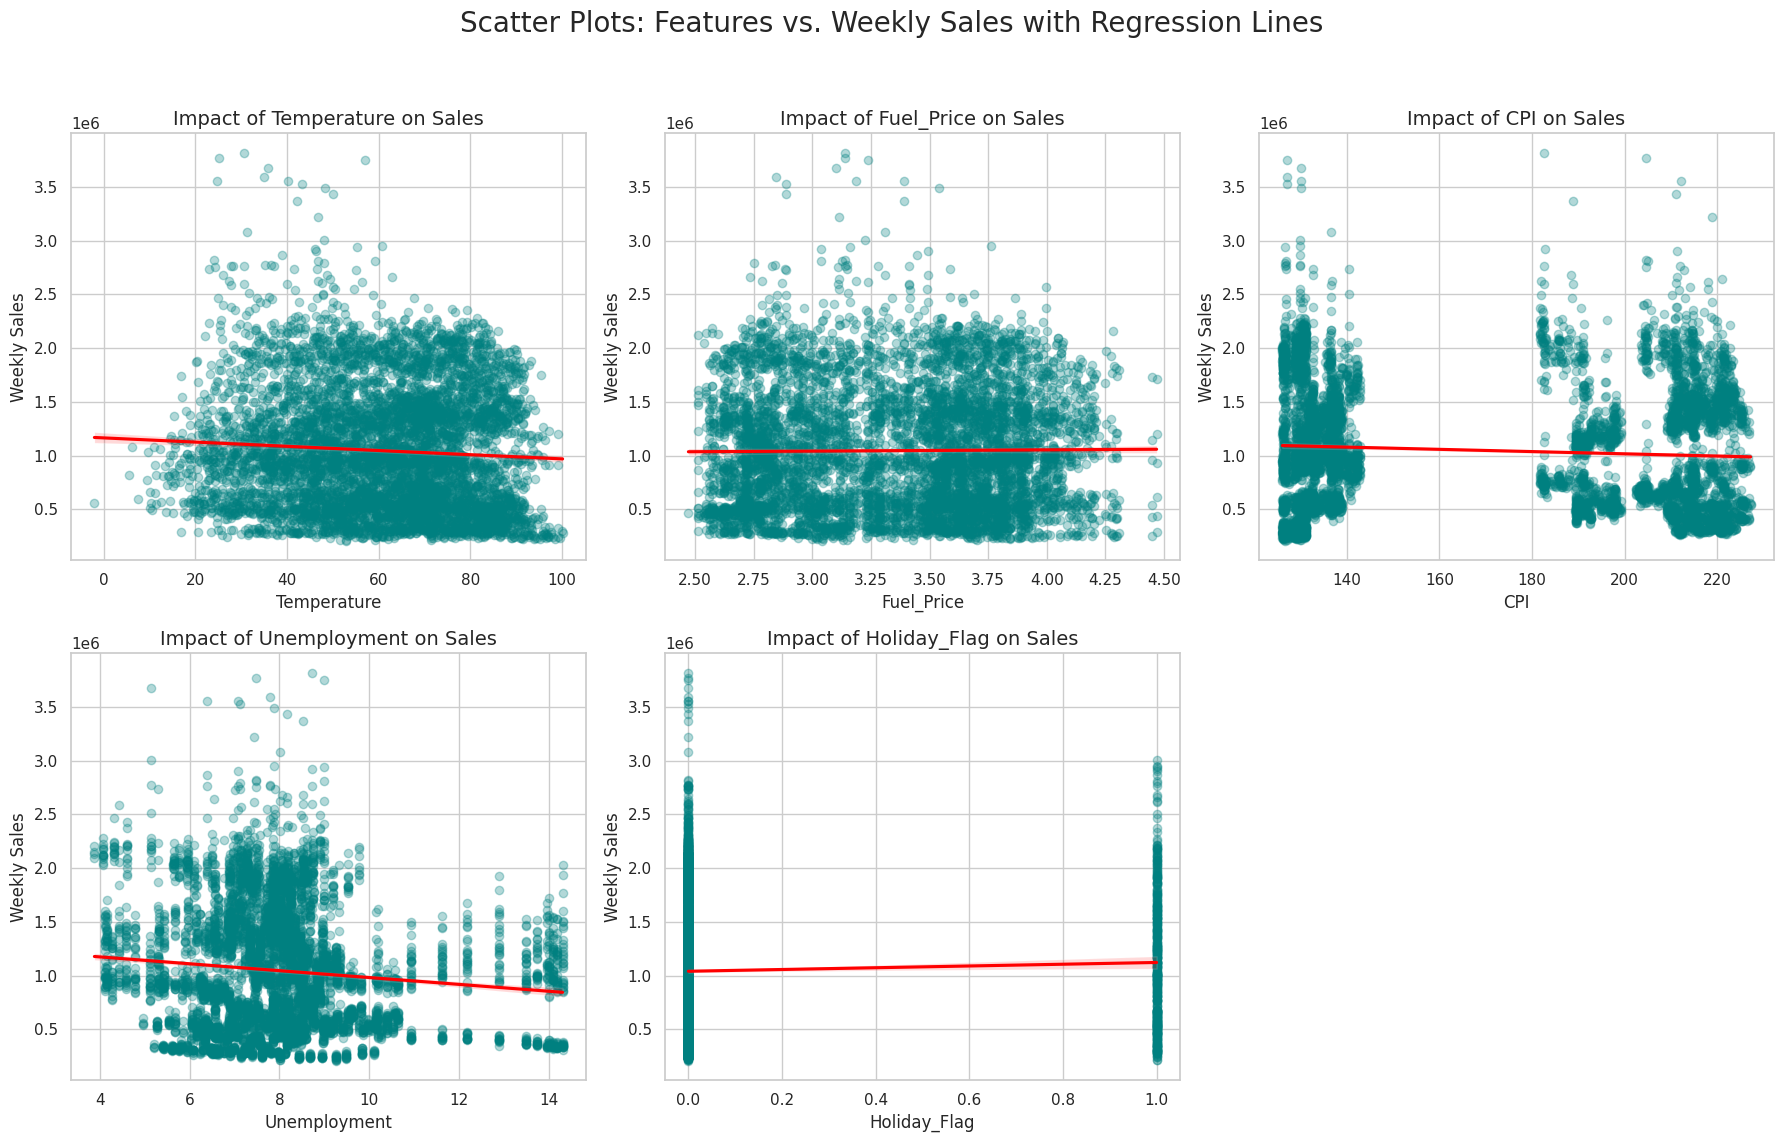

In [45]:
# --- 2. Setup Variables for Analysis ---
# We define independent variables to check their impact on 'Weekly_Sales'
independent_vars = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Holiday_Flag']

# --- 3. Visualization Setup (Scatter Plots) ---
# Creating a grid of subplots (2 rows by 3 columns)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
fig.suptitle('Scatter Plots: Features vs. Weekly Sales with Regression Lines', fontsize=20)

# --- 4. Loop Through Features to Plot ---
for i, var in enumerate(independent_vars):
    # Calculate the current position in the grid
    row = i // 3
    col = i % 3

    # sns.regplot draws a scatter plot and a linear regression model fit (Red Line)
    # alpha=0.3 helps visualize point density where data overlaps
    sns.regplot(data=df, x=var, y='Weekly_Sales', ax=axes[row, col],
                scatter_kws={'alpha':0.3, 'color':'teal'},
                line_kws={'color':'red'})

    # Adding professional English labels and titles
    axes[row, col].set_title(f'Impact of {var} on Sales', fontsize=14)
    axes[row, col].set_xlabel(var)
    axes[row, col].set_ylabel('Weekly Sales')

# --- 5. Final Cleanup ---
# Remove the empty 6th subplot since we only have 5 features
fig.delaxes(axes[1, 2])

# Adjust layout to prevent text overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Display the final visualization
plt.show()

In [18]:
holiday_comparison = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()
print(holiday_comparison)

Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64


/tmp/ipykernel_38553/3029671889.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Holiday_Flag', y='Weekly_Sales', palette='Set2')


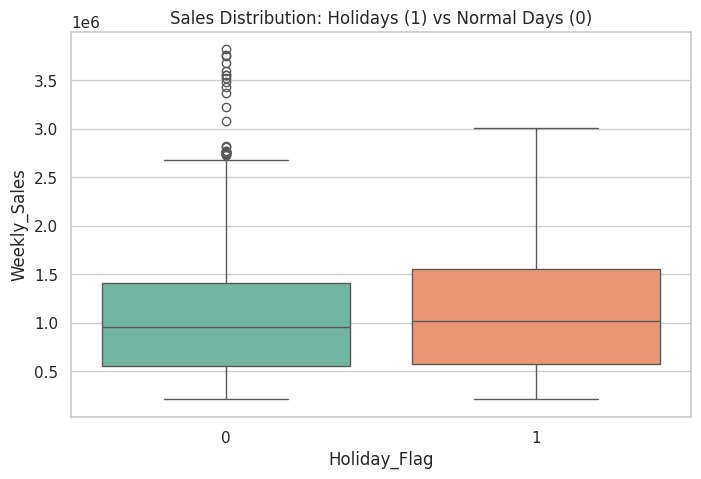

In [31]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Holiday_Flag', y='Weekly_Sales', palette='Set2')
plt.title('Sales Distribution: Holidays (1) vs Normal Days (0)')
plt.show()

In [49]:
branch_averages = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False).reset_index()

print("Top 10 Stores by Average Weekly Sales:")
print(branch_averages.head(10))

Top 10 Stores by Average Weekly Sales:
   Store  Weekly_Sales
0     20  2.107677e+06
1      4  2.094713e+06
2     14  2.020978e+06
3     13  2.003620e+06
4      2  1.925751e+06
5     10  1.899425e+06
6     27  1.775216e+06
7      6  1.564728e+06
8      1  1.555264e+06
9     39  1.450668e+06


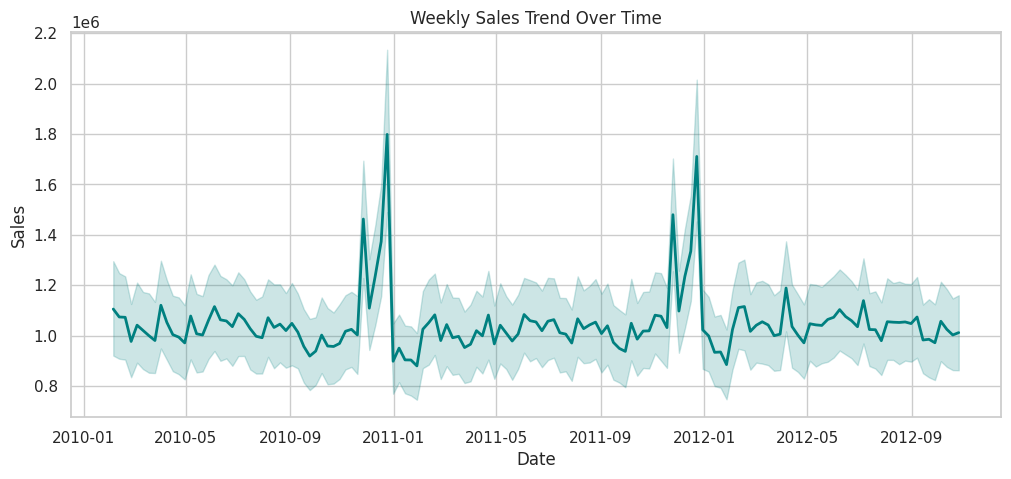

In [35]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='Date', y='Weekly_Sales', color='teal', linewidth=2)
plt.title('Weekly Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

The visualization shows an increase during the last two years (2011 and 2012), which indicates the presence of seasonality.

In [36]:
import statsmodels.api as sm

# 1. Prepare your Features (Independent Variables) and Target (Weekly_Sales)
# We include all relevant numeric columns from your data
X = df[['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Holiday_Flag']]
y = df['Weekly_Sales']

# 2. Add a Constant (Intercept) to the model
# In statistics, this represents the baseline sales when all factors are zero
X = sm.add_constant(X)

# 3. Fit the Ordinary Least Squares (OLS) Model
model = sm.OLS(y, X).fit()

# 4. Extract Coefficients to build the final equation
intercept = model.params['const']
coeffs = model.params.drop('const')

# 5. Print the Final Statistical Equation
print("--- Final Statistical Regression Equation ---")
equation = f"Weekly_Sales = {intercept:.2f}"
for col, val in coeffs.items():
    sign = "+" if val >= 0 else "-"
    equation += f" {sign} ({abs(val):.2f} * {col})"

print(equation)

--- Final Statistical Regression Equation ---
Weekly_Sales = 1726523.39 - (724.17 * Temperature) - (10167.88 * Fuel_Price) - (1598.87 * CPI) - (41552.28 * Unemployment) + (74891.66 * Holiday_Flag)


multiple linear regression model can be used to describe the majority of the data

ML Model

Preprocessing Data

In [37]:

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)

X = df[['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Week']]
y = df['Weekly_Sales']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
print(f"Linear Regression R2: {r2_score(y_test, lr_preds)}")

Linear Regression R2: 0.15553160499602847


very low

In [39]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
print(f"XGBoost R2: {r2_score(y_test, xgb_preds)}")

XGBoost R2: 0.9685467370197967


High R2

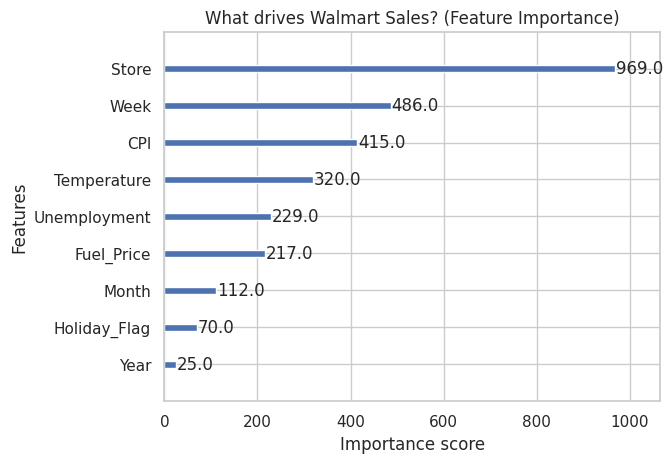

In [40]:
import matplotlib.pyplot as plt

xgb.plot_importance(xgb_model)
plt.title('What drives Walmart Sales? (Feature Importance)')
plt.show()

Strongest Predictors